In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("SAP/Capstone Project/uber.csv")

In [3]:
df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [7]:
# Fare should be positive and reasonable
df = df[df['fare_amount'] > 0]
df = df[df['fare_amount'] < 100]

# Passenger count valid
df = df[df['passenger_count'] > 0]
df = df[df['passenger_count'] < 7]

In [8]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [9]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance'] = haversine(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])

In [11]:
X = df[['distance', 'hour', 'day', 'passenger_count']]
y = df['fare_amount']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [15]:
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Linear Regression RSME:", mean_squared_error(y_test, y_pred))

Linear Regression MAE: 5.995911354739909
Linear Regression R2: 0.00176102323093974
Linear Regression RSME: 89.24113511860183


In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [18]:
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, y_pred))
print("Random Forest RSME:", mean_squared_error(y_test, y_pred))

Random Forest MAE: 2.6046747214929376
Random Forest R2: 0.7337492899194497
Random Forest RSME: 23.802432229831673


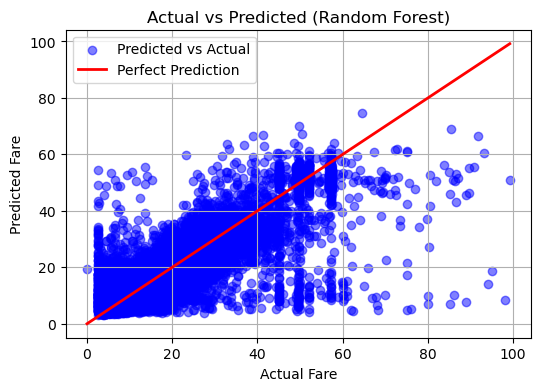

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

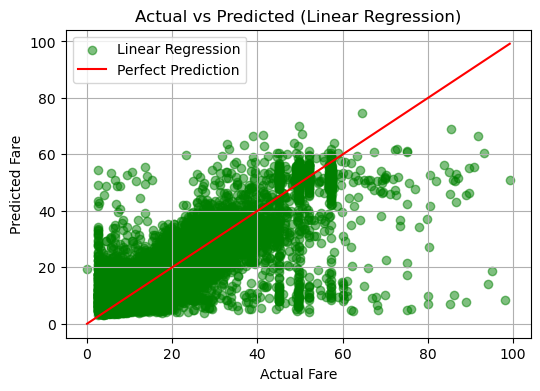

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, color='green', alpha=0.5, label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)

plt.show()